# LAPORAN SISTEM INFERENSI FUZZY

## Identitas
**Nama:** Wayan Raditya Putra
**NRP:** 5054241029
**Program Studi:** RKA

> *“Fuzzy logic is not about being vague, but about describing the real world precisely.”*  
> — Lotfi A. Zadeh


In [93]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt


In [94]:
# Input
kualitas = np.arange(0, 10.1, 0.1)
pelayanan = np.arange(0, 10.1, 0.1)
harga = np.arange(20000, 200001, 1000)

# Output
kepuasan = np.arange(0, 101, 1)


In [95]:
# Kualitas Makanan
kualitas_buruk = fuzz.trapmf(kualitas, [0, 0, 2, 4])      # dari [0,0,4] → sedikit overlap ke 2
kualitas_sedang = fuzz.trapmf(kualitas, [3, 4, 6, 7])     # masih dalam (3–7)
kualitas_bagus = fuzz.trapmf(kualitas, [6, 8, 10, 10])    # masih dalam (6–10)

# Pelayanan
pelayanan_buruk = fuzz.trapmf(pelayanan, [0, 0, 2, 4])
pelayanan_sedang = fuzz.trapmf(pelayanan, [3, 4, 6, 7])
pelayanan_bagus = fuzz.trapmf(pelayanan, [6, 8, 10, 10])

# Harga (dalam ribuan)
harga_murah = fuzz.trapmf(harga, [20000, 20000, 40000, 80000])
harga_sedang = fuzz.trapmf(harga, [60000, 80000, 120000, 140000])
harga_mahal = fuzz.trapmf(harga, [120000, 160000, 200000, 200000])

# Kepuasan Pelanggan
kepuasan_rendah = fuzz.trapmf(kepuasan, [0, 0, 20, 40])
kepuasan_sedang = fuzz.trapmf(kepuasan, [30, 40, 60, 70])
kepuasan_tinggi = fuzz.trapmf(kepuasan, [60, 80, 100, 100])

# Tsukamoto tetap pakai yang halus (zmf, gaussmf, smf)
kepuasan_tsukamoto = np.arange(0, 101, 1)
kepuasan_rendah_tsu = fuzz.zmf(kepuasan_tsukamoto, 30, 60)
kepuasan_sedang_tsu = fuzz.gaussmf(kepuasan_tsukamoto, 50, 10)
kepuasan_tinggi_tsu = fuzz.smf(kepuasan_tsukamoto, 40, 70)


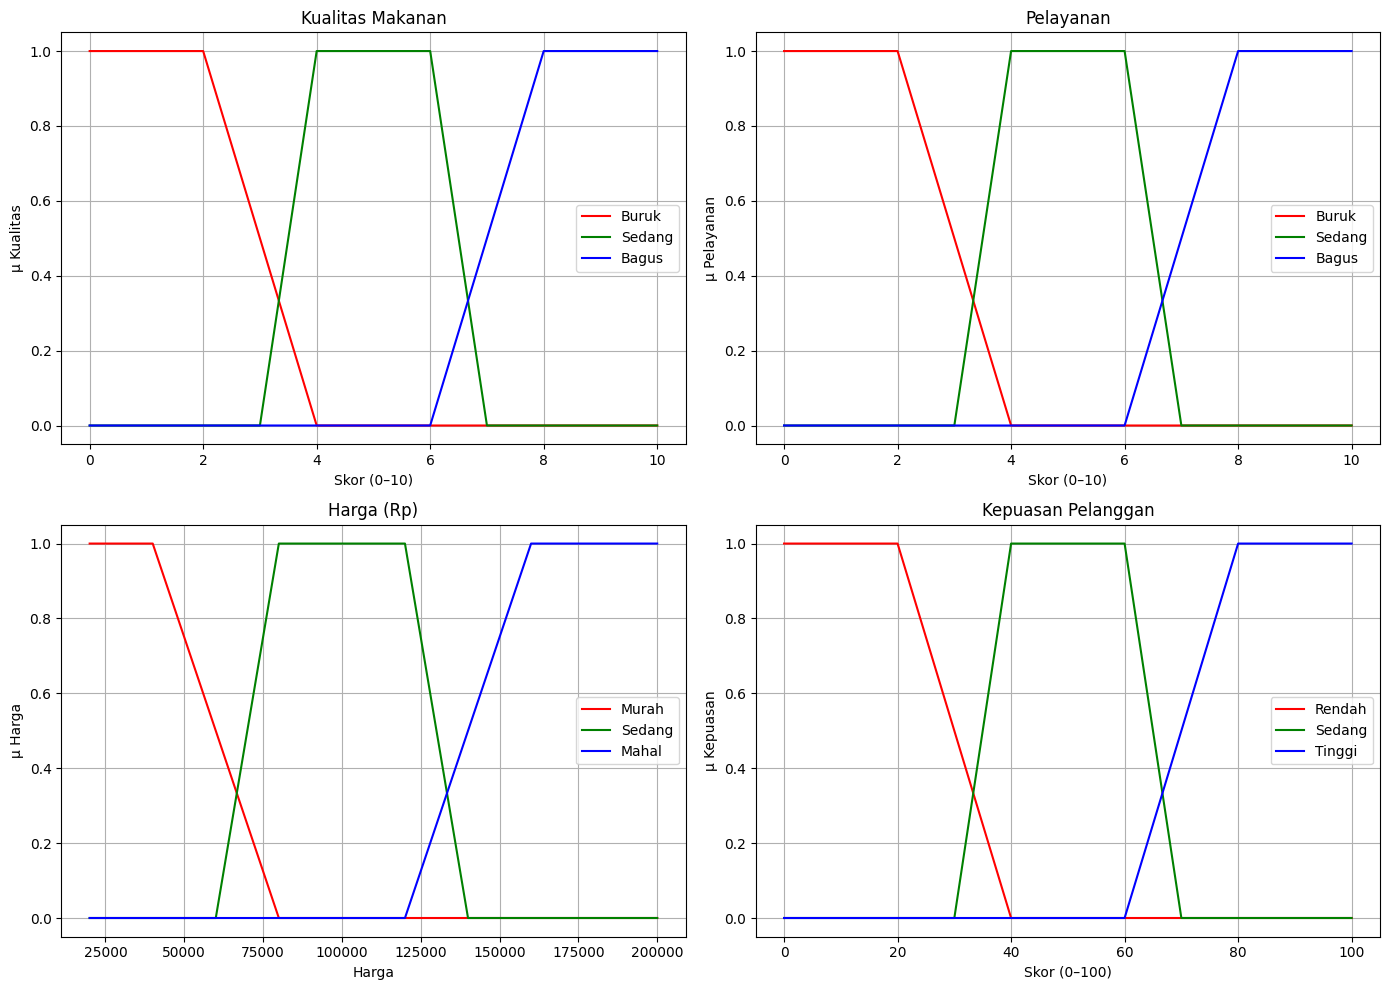

In [96]:
plt.figure(figsize=(14, 10))

# Plot Kualitas
plt.subplot(2, 2, 1)
plt.plot(kualitas, kualitas_buruk, 'r', label='Buruk')
plt.plot(kualitas, kualitas_sedang, 'g', label='Sedang')
plt.plot(kualitas, kualitas_bagus, 'b', label='Bagus')
plt.title('Kualitas Makanan')
plt.xlabel('Skor (0–10)')
plt.ylabel('μ Kualitas')
plt.legend()
plt.grid(True)

# Plot Pelayanan
plt.subplot(2, 2, 2)
plt.plot(pelayanan, pelayanan_buruk, 'r', label='Buruk')
plt.plot(pelayanan, pelayanan_sedang, 'g', label='Sedang')
plt.plot(pelayanan, pelayanan_bagus, 'b', label='Bagus')
plt.title('Pelayanan')
plt.xlabel('Skor (0–10)')
plt.ylabel('μ Pelayanan')
plt.legend()
plt.grid(True)

# Plot Harga
plt.subplot(2, 2, 3)
plt.plot(harga, harga_murah, 'r', label='Murah')
plt.plot(harga, harga_sedang, 'g', label='Sedang')
plt.plot(harga, harga_mahal, 'b', label='Mahal')
plt.title('Harga (Rp)')
plt.xlabel('Harga')
plt.ylabel('μ Harga')
plt.legend()
plt.grid(True)

# Plot Kepuasan
plt.subplot(2, 2, 4)
plt.plot(kepuasan, kepuasan_rendah, 'r', label='Rendah')
plt.plot(kepuasan, kepuasan_sedang, 'g', label='Sedang')
plt.plot(kepuasan, kepuasan_tinggi, 'b', label='Tinggi')
plt.title('Kepuasan Pelanggan')
plt.xlabel('Skor (0–100)')
plt.ylabel('μ Kepuasan')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 📘 **Basis Aturan Fuzzy (Rule Base)**

1. IF *Kualitas* Bagus AND *Pelayanan* Bagus AND *Harga* Murah → *Kepuasan* Tinggi  
2. IF *Kualitas* Bagus AND *Pelayanan* Sedang AND *Harga* Sedang → *Kepuasan* Tinggi  
3. IF *Kualitas* Bagus AND *Pelayanan* Bagus AND *Harga* Mahal → *Kepuasan* Sedang  
4. IF *Kualitas* Sedang AND *Pelayanan* Sedang AND *Harga* Sedang → *Kepuasan* Sedang  
5. IF *Kualitas* Buruk AND *Pelayanan* Buruk AND *Harga* Murah → *Kepuasan* Sedang  
6. IF *Kualitas* Buruk AND *Pelayanan* Buruk AND *Harga* Mahal → *Kepuasan* Rendah  
7. IF *Kualitas* Sedang AND *Pelayanan* Bagus AND *Harga* Sedang → *Kepuasan* Tinggi  
8. IF *Kualitas* Bagus AND *Pelayanan* Buruk AND *Harga* Mahal → *Kepuasan* Sedang  
9. IF *Kualitas* Buruk AND *Pelayanan* Sedang AND *Harga* Murah → *Kepuasan* Rendah  
10. IF *Kualitas* Sedang AND *Pelayanan* Bagus AND *Harga* Murah → *Kepuasan* Tinggi  
11. IF *Kualitas* Sedang AND *Pelayanan* Buruk AND *Harga* Mahal → *Kepuasan* Rendah  
12. IF *Kualitas* Bagus AND *Pelayanan* Buruk AND *Harga* Murah → *Kepuasan* Sedang  
13. IF *Kualitas* Bagus AND *Pelayanan* Sedang AND *Harga* Mahal → *Kepuasan* Sedang  
14. IF *Kualitas* Bagus AND *Pelayanan* Sedang AND *Harga* Murah → *Kepuasan* Tinggi  



### 💡 *Penjelasan Pola Aturan*

Aturan di atas dirancang untuk menyeimbangkan pengaruh antara *kualitas*, *pelayanan*, dan *harga* secara realistis:

- **Kepuasan Tinggi** (Rules 1, 2, 7, 10, 14)  
  Terjadi saat kualitas dan pelayanan bagus dengan harga yang masih tergolong wajar atau murah.

- **Kepuasan Sedang** (Rules 3, 4, 5, 8, 12, 13)  
  Muncul pada kombinasi kualitas bagus tapi harga mahal, atau kondisi pelayanan sedang.

- **Kepuasan Rendah** (Rules 6, 9, 11)  
  Mewakili kasus buruk: kualitas dan pelayanan rendah, atau harga tinggi tanpa diimbangi pelayanan yang baik.


In [107]:
def basis_aturan(derajat_kualitas, derajat_pelayanan, derajat_harga, mf_output):
    """
    derajat_kualitas, derajat_pelayanan, derajat_harga: dict
        contoh: {'buruk': 0.2, 'sedang': 0.7, 'bagus': 0.9}
    mf_output: dict
        contoh: {'rendah': kepuasan_rendah, 'sedang': kepuasan_sedang, 'tinggi': kepuasan_tinggi}
    return: dict of rule outputs
    """
    rules = {}

    # 1. Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi
    r1 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['bagus']), derajat_harga['murah'])
    rules['rule1'] = np.fmin(r1, mf_output['tinggi'])

    # 2. Kualitas Bagus ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Tinggi
    r2 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['sedang']), derajat_harga['sedang'])
    rules['rule2'] = np.fmin(r2, mf_output['tinggi'])

    # 3. Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Mahal → Kepuasan Sedang
    r3 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['bagus']), derajat_harga['mahal'])
    rules['rule3'] = np.fmin(r3, mf_output['sedang'])

    # 4. Kualitas Sedang ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Sedang
    r4 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['sedang']), derajat_harga['sedang'])
    rules['rule4'] = np.fmin(r4, mf_output['sedang'])

    # 5. Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang
    r5 = np.fmin(np.fmin(derajat_kualitas['buruk'], derajat_pelayanan['buruk']), derajat_harga['murah'])
    rules['rule5'] = np.fmin(r5, mf_output['sedang'])

    # 6. Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah
    r6 = np.fmin(np.fmin(derajat_kualitas['buruk'], derajat_pelayanan['buruk']), derajat_harga['mahal'])
    rules['rule6'] = np.fmin(r6, mf_output['rendah'])

    # 7. Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Sedang → Kepuasan Tinggi
    r7 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['bagus']), derajat_harga['sedang'])
    rules['rule7'] = np.fmin(r7, mf_output['tinggi'])

    # 8. Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Sedang
    r8 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['buruk']), derajat_harga['mahal'])
    rules['rule8'] = np.fmin(r8, mf_output['sedang'])

    # 9. Kualitas Buruk ∧ Pelayanan Sedang ∧ Harga Murah → Kepuasan Rendah
    r9 = np.fmin(np.fmin(derajat_kualitas['buruk'], derajat_pelayanan['sedang']), derajat_harga['murah'])
    rules['rule9'] = np.fmin(r9, mf_output['rendah'])

    # 10. Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi
    r10 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['bagus']), derajat_harga['murah'])
    rules['rule10'] = np.fmin(r10, mf_output['tinggi'])

    # 11. Kualitas Sedang ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah
    r11 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['buruk']), derajat_harga['mahal'])
    rules['rule11'] = np.fmin(r11, mf_output['rendah'])

    # 12. Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang
    r12 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['buruk']), derajat_harga['murah'])
    rules['rule12'] = np.fmin(r12, mf_output['sedang'])

     # Bagus ∧ Sedang ∧ Mahal → Sedang
    rules['rule13'] = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['sedang']), derajat_harga['mahal'])
    rules['rule13'] = np.fmin(rules['rule13'], mf_output['sedang'])

    # Bagus ∧ Sedang ∧ Murah → Tinggi
    rules['rule14'] = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['sedang']), derajat_harga['murah'])
    rules['rule14'] = np.fmin(rules['rule14'], mf_output['tinggi'])

     # --- Fallback rule universal (default netral) ---
    # Jika semua rule bernilai 0, sistem tetap memberikan output kepuasan sedang
    rules['rule_fallback'] = np.fmin(1, mf_output['sedang'])

    for i, (_, v) in enumerate(rules.items(), 1):
        print(f"Rule {i}: max={np.max(v):.3f}")


    return rules


In [108]:
def demo_rules_visualization():
    """
    Visualisasi demonstratif dari 12 rule fuzzy tanpa input spesifik.
    Tujuan: menunjukkan efek clipping (pemotongan) pada fungsi output
    untuk masing-masing rule.

    Catatan:
    - Menggunakan nilai alpha (derajat firing) tetap atau representatif.
    - Cocok untuk laporan / penjelasan teori fuzzy.
    """
    fig, axes = plt.subplots(4, 3, figsize=(18, 14))
    axes = axes.flatten()

    # Daftar aturan dan parameter firing strength (alpha) untuk tiap rule
    rules_demo = [
        ("Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi", 0.7, kepuasan_tinggi),
        ("Kualitas Bagus ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Tinggi", 0.6, kepuasan_tinggi),
        ("Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Mahal → Kepuasan Sedang", 0.5, kepuasan_sedang),
        ("Kualitas Sedang ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Sedang", 0.6, kepuasan_sedang),
        ("Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang", 0.4, kepuasan_sedang),
        ("Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah", 0.8, kepuasan_rendah),
        ("Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Sedang → Kepuasan Tinggi", 0.7, kepuasan_tinggi),
        ("Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Sedang", 0.5, kepuasan_sedang),
        ("Kualitas Buruk ∧ Pelayanan Sedang ∧ Harga Murah → Kepuasan Rendah", 0.6, kepuasan_rendah),
        ("Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi", 0.8, kepuasan_tinggi),
        ("Kualitas Sedang ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah", 0.5, kepuasan_rendah),
        ("Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang", 0.6, kepuasan_sedang)
    ]

    # Plot setiap rule dengan clipping
    for i, (judul, alpha, konsekuen) in enumerate(rules_demo):
        activation = np.fmin(alpha, konsekuen)
        ax = axes[i]
        ax.plot(kepuasan, konsekuen, 'k--', linewidth=0.8, alpha=0.6)
        ax.fill_between(kepuasan, 0, activation, facecolor='orange', alpha=0.7)
        ax.set_title(f"Rule {i+1}: {judul}", fontsize=9)
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 1.05)
        ax.grid(True)

    plt.suptitle("Demonstrasi 12 Rule Fuzzy (Efek Clipping pada Output)", fontsize=14, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


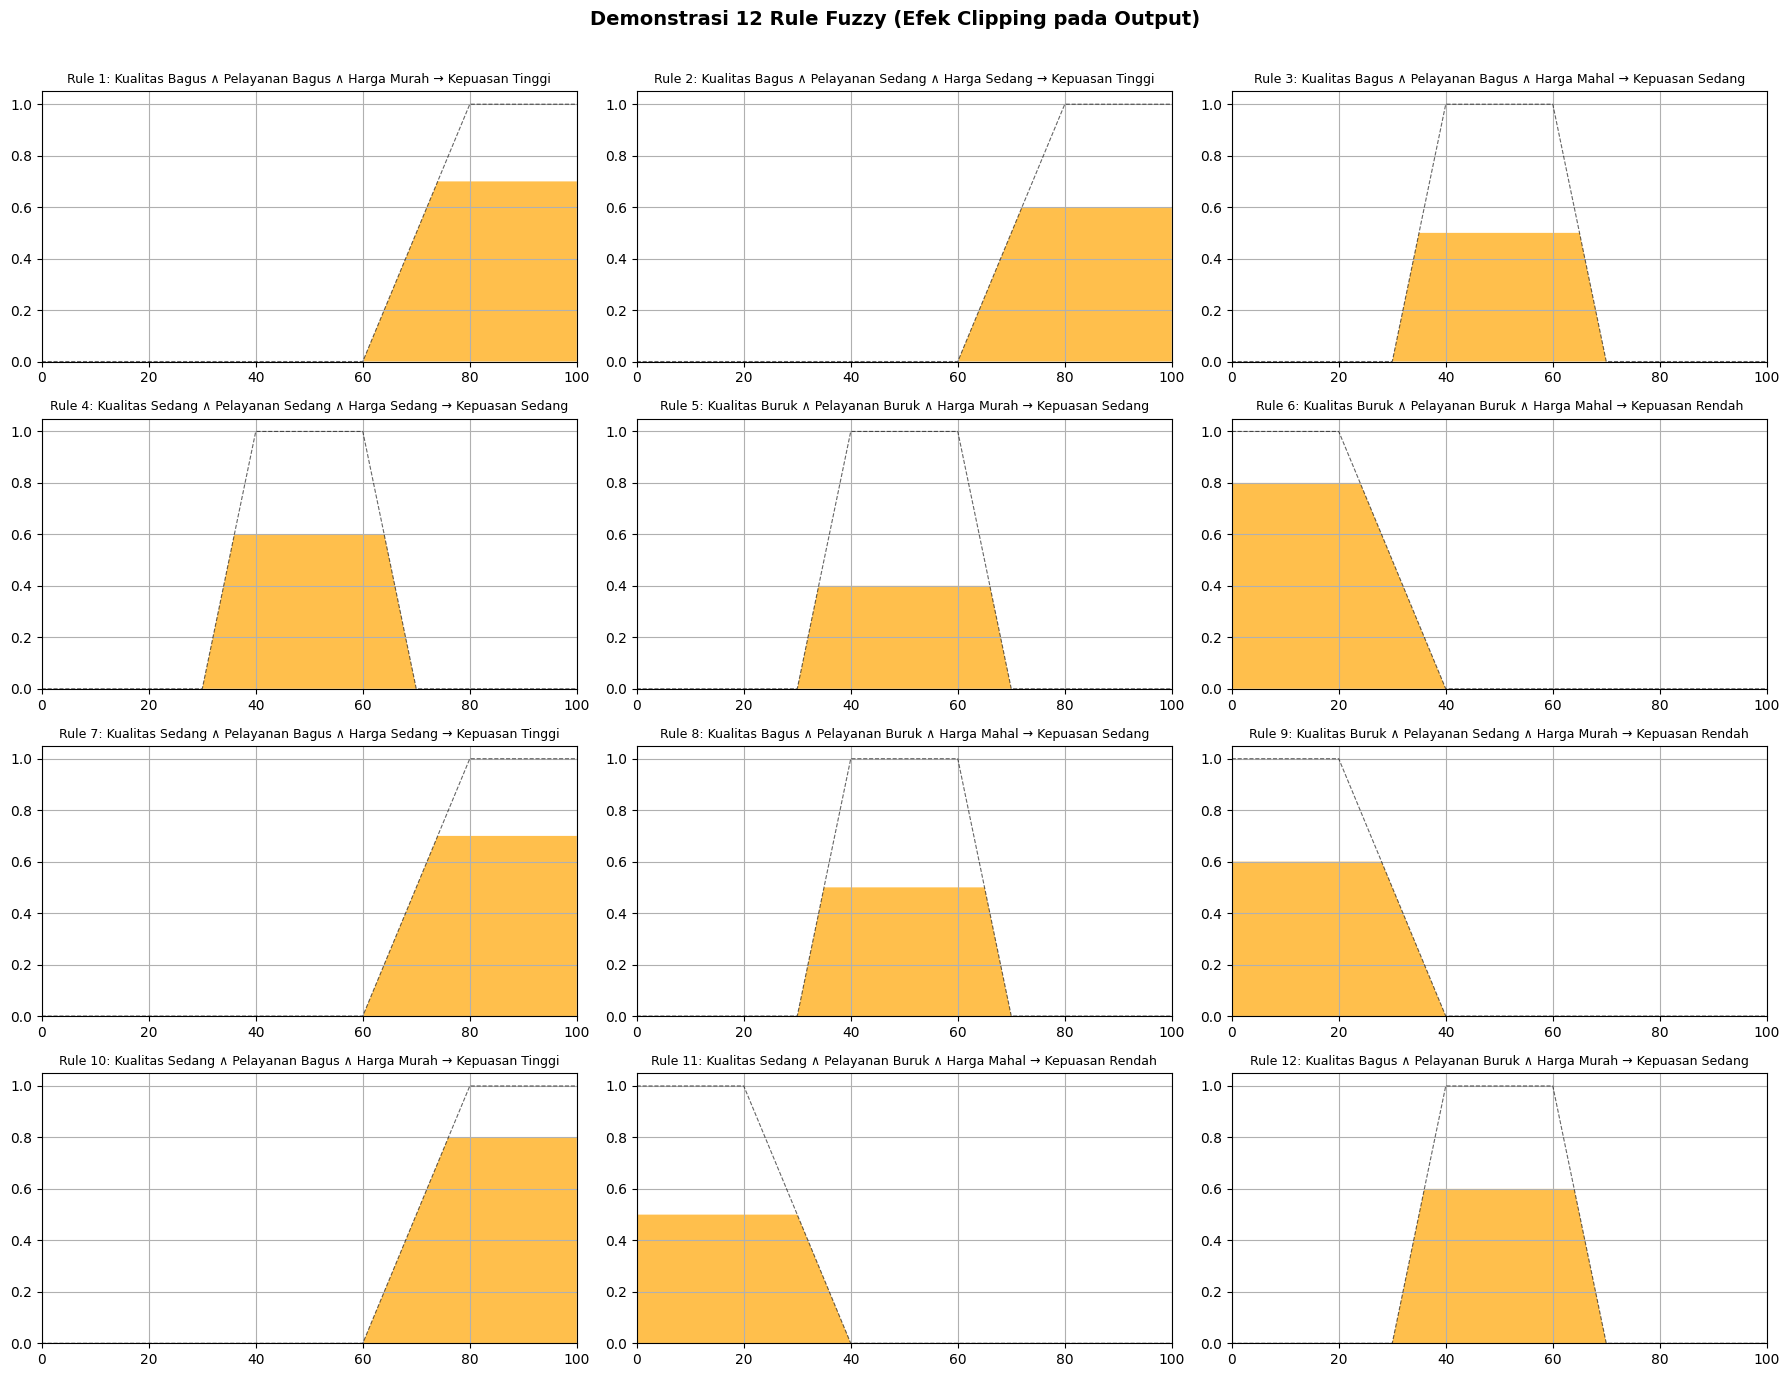

In [109]:
demo_rules_visualization()

In [110]:
def visualisasi_output(domain, aggregated, crisp_value, title="Hasil Fuzzy Mamdani"):
    """
    Menampilkan grafik hasil agregasi fuzzy dan titik defuzzifikasi (centroid).
    domain       : np.array domain output (contoh: kepuasan)
    aggregated   : hasil gabungan dari semua rule
    crisp_value  : nilai defuzzifikasi (centroid)
    """
    plt.figure(figsize=(8, 4))

    
    
    if len(aggregated) != len(domain):
        # Buat garis horizontal sekadar representasi firing strength
        plt.plot(domain, np.ones_like(domain) * 0.5, '--', color='gray', alpha=0.5)
        plt.axvline(crisp_value, color='k', linewidth=2, label='Output Crisp (Weighted Avg)')
        plt.title(title + " — (Representatif Weighted Average)")
        plt.xlabel('Kepuasan (0–100)')
        plt.ylabel('Derajat Keanggotaan')
        plt.legend()
        plt.grid(True)
        plt.show()
        return


    activation = fuzz.interp_membership(domain, aggregated, crisp_value)
    plt.fill_between(domain, 0, aggregated, facecolor='orange', alpha=0.7, label='Agregasi Output')
    plt.plot([crisp_value, crisp_value], [0, activation], 'k', linewidth=2, label='Centroid')
    plt.title(title)
    plt.xlabel('Kepuasan (0–100)')
    plt.ylabel('Derajat Keanggotaan')
    plt.legend()
    plt.grid(True)
    plt.show()


In [111]:
def mamdani(input_kualitas, input_pelayanan, input_harga):
    # Fuzzifikasi input
    derajat_kualitas_buruk = fuzz.interp_membership(kualitas, kualitas_buruk, input_kualitas)
    derajat_kualitas_sedang = fuzz.interp_membership(kualitas, kualitas_sedang, input_kualitas)
    derajat_kualitas_bagus = fuzz.interp_membership(kualitas, kualitas_bagus, input_kualitas)

    derajat_pelayanan_buruk = fuzz.interp_membership(pelayanan, pelayanan_buruk, input_pelayanan)
    derajat_pelayanan_sedang = fuzz.interp_membership(pelayanan, pelayanan_sedang, input_pelayanan)
    derajat_pelayanan_bagus = fuzz.interp_membership(pelayanan, pelayanan_bagus, input_pelayanan)

    derajat_harga_murah = fuzz.interp_membership(harga, harga_murah, input_harga)
    derajat_harga_sedang = fuzz.interp_membership(harga, harga_sedang, input_harga)
    derajat_harga_mahal = fuzz.interp_membership(harga, harga_mahal, input_harga)

    derajat_kualitas = {
    'buruk': derajat_kualitas_buruk,
    'sedang': derajat_kualitas_sedang,
    'bagus': derajat_kualitas_bagus
    }
    derajat_pelayanan = {
        'buruk': derajat_pelayanan_buruk,
        'sedang': derajat_pelayanan_sedang,
        'bagus': derajat_pelayanan_bagus
    }
    derajat_harga = {
        'murah': derajat_harga_murah,
        'sedang': derajat_harga_sedang,
        'mahal': derajat_harga_mahal
    }

    mf_output = {
    'rendah': kepuasan_rendah,
    'sedang': kepuasan_sedang,
    'tinggi': kepuasan_tinggi
    }


    rules = basis_aturan(derajat_kualitas, derajat_pelayanan, derajat_harga, mf_output)
    aggregated_mamdani = np.fmax.reduce(list(rules.values()))

    if np.sum(aggregated_mamdani) == 0:
        output_crisp = 0
        label_dominan = 'tidak terdefinisi'

    else : 
        output_crisp = fuzz.defuzz(kepuasan, aggregated_mamdani, 'centroid')

        dom_rendah = fuzz.interp_membership(kepuasan, kepuasan_rendah, output_crisp)
        dom_sedang = fuzz.interp_membership(kepuasan, kepuasan_sedang, output_crisp)
        dom_tinggi = fuzz.interp_membership(kepuasan, kepuasan_tinggi, output_crisp)

        derajat_label = {
        'rendah': dom_rendah,
        'sedang': dom_sedang,
        'tinggi': dom_tinggi
        }
        
        label_dominan = max(derajat_label, key=derajat_label.get)

    return {
        'crisp': output_crisp,
        'aggregated': aggregated_mamdani,
        'rules': rules,
        'label': label_dominan,
        'mf_output' : mf_output
    }


    

    





In [112]:
def sugeno(input_kualitas, input_pelayanan, input_harga):
    """
    Sistem Inferensi Fuzzy Sugeno (Weighted Average)
    """
    # 1. Fuzzifikasi input
    
    derajat_kualitas_buruk = fuzz.interp_membership(kualitas, kualitas_buruk, input_kualitas)
    derajat_kualitas_sedang = fuzz.interp_membership(kualitas, kualitas_sedang, input_kualitas)
    derajat_kualitas_bagus = fuzz.interp_membership(kualitas, kualitas_bagus, input_kualitas)

    derajat_pelayanan_buruk = fuzz.interp_membership(pelayanan, pelayanan_buruk, input_pelayanan)
    derajat_pelayanan_sedang = fuzz.interp_membership(pelayanan, pelayanan_sedang, input_pelayanan)
    derajat_pelayanan_bagus = fuzz.interp_membership(pelayanan, pelayanan_bagus, input_pelayanan)

    derajat_harga_murah = fuzz.interp_membership(harga, harga_murah, input_harga)
    derajat_harga_sedang = fuzz.interp_membership(harga, harga_sedang, input_harga)
    derajat_harga_mahal = fuzz.interp_membership(harga, harga_mahal, input_harga)

    
    # 2. Hitung firing strength (a) untuk tiap rule
    
    a1 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_bagus), derajat_harga_murah)
    a2 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_sedang), derajat_harga_sedang)
    a3 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_bagus), derajat_harga_mahal)
    a4 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_sedang), derajat_harga_sedang)
    a5 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_buruk), derajat_harga_murah)
    a6 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_buruk), derajat_harga_mahal)
    a7 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_bagus), derajat_harga_sedang)
    a8 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_buruk), derajat_harga_mahal)
    a9 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_sedang), derajat_harga_murah)
    a10 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_bagus), derajat_harga_murah)
    a11 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_buruk), derajat_harga_mahal)
    a12 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_buruk), derajat_harga_murah)

    a = np.array([a1, a2, a3, a4, a5, a6, a7, a8, a9, a10, a11, a12])

    
    # 3. Output tiap rule (z_i)

    # Menggunakan konstanta representatif (0–100)
    z_i = np.array([75, 75, 50, 50, 50, 25, 75, 50, 25, 75, 25, 50])

    
    # 4. Weighted Average Defuzzifikasi
    if np.sum(a) == 0:
        output_crisp = 0
    else:
        output_crisp = np.sum(a * z_i) / np.sum(a)


    # 5. Tentukan label linguistik
    dom_rendah = fuzz.interp_membership(kepuasan, kepuasan_rendah, output_crisp)
    dom_sedang = fuzz.interp_membership(kepuasan, kepuasan_sedang, output_crisp)
    dom_tinggi = fuzz.interp_membership(kepuasan, kepuasan_tinggi, output_crisp)

    derajat_label = {
        'rendah': dom_rendah,
        'sedang': dom_sedang,
        'tinggi': dom_tinggi
    }
    label_dominan = max(derajat_label, key=derajat_label.get)


    # 6. Return hasil (konsisten dengan pipeline)
    return {
        'crisp': output_crisp,
        'label': label_dominan,
        'aggregated': None,     #Sugeno tidak punya fuzzy output
        'rules': None,          #Tidak perlu visualisasi area per rule
        'mf_output': {
            'rendah': kepuasan_rendah,
            'sedang': kepuasan_sedang,
            'tinggi': kepuasan_tinggi
        }
    }


In [113]:
def tsukamoto(input_kualitas, input_pelayanan, input_harga):
    """
    Sistem Inferensi Fuzzy Tsukamoto (Weighted Average)
    """
    # 1. Fuzzifikasi input
    derajat_kualitas_buruk = fuzz.interp_membership(kualitas, kualitas_buruk, input_kualitas)
    derajat_kualitas_sedang = fuzz.interp_membership(kualitas, kualitas_sedang, input_kualitas)
    derajat_kualitas_bagus = fuzz.interp_membership(kualitas, kualitas_bagus, input_kualitas)

    derajat_pelayanan_buruk = fuzz.interp_membership(pelayanan, pelayanan_buruk, input_pelayanan)
    derajat_pelayanan_sedang = fuzz.interp_membership(pelayanan, pelayanan_sedang, input_pelayanan)
    derajat_pelayanan_bagus = fuzz.interp_membership(pelayanan, pelayanan_bagus, input_pelayanan)

    derajat_harga_murah = fuzz.interp_membership(harga, harga_murah, input_harga)
    derajat_harga_sedang = fuzz.interp_membership(harga, harga_sedang, input_harga)
    derajat_harga_mahal = fuzz.interp_membership(harga, harga_mahal, input_harga)


    # 2. Firing strength (a_i)
    a1 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_bagus), derajat_harga_murah)
    a2 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_sedang), derajat_harga_sedang)
    a3 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_bagus), derajat_harga_mahal)
    a4 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_sedang), derajat_harga_sedang)
    a5 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_buruk), derajat_harga_murah)
    a6 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_buruk), derajat_harga_mahal)
    a7 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_bagus), derajat_harga_sedang)
    a8 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_buruk), derajat_harga_mahal)
    a9 = np.fmin(np.fmin(derajat_kualitas_buruk, derajat_pelayanan_sedang), derajat_harga_murah)
    a10 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_bagus), derajat_harga_murah)
    a11 = np.fmin(np.fmin(derajat_kualitas_sedang, derajat_pelayanan_buruk), derajat_harga_mahal)
    a12 = np.fmin(np.fmin(derajat_kualitas_bagus, derajat_pelayanan_buruk), derajat_harga_murah)

    a = np.array([a1, a2, a3, a4, a5, a6, a7, a8, a9, a10, a11, a12])

    # 3. Tentukan label output tiap rule
    label_rule = ['tinggi', 'tinggi', 'sedang', 'sedang', 'sedang', 'rendah',
                  'tinggi', 'sedang', 'rendah', 'tinggi', 'rendah', 'sedang']


    # 4. Cari nilai crisp (z_i) untuk tiap rule
    z_i = []
    for i, label in enumerate(label_rule):
        if a[i] == 0:
            z_i.append(0)
        else:
            # Ambil fungsi keanggotaan sesuai label
            mf = {
                'rendah': kepuasan_rendah_tsu,
                'sedang': kepuasan_sedang_tsu,
                'tinggi': kepuasan_tinggi_tsu
            }[label]

            # Cari titik di domain kepuasan di mana μ = a[i] (inverse membership)
            μ = mf
            idx = np.argmin(np.abs(μ - a[i]))
            z_i.append(kepuasan[idx])

    z_i = np.array(z_i)


    # 5. Defuzzifikasi Weighted Average
    if np.sum(a) == 0:
        output_crisp = 0
    else:
        output_crisp = np.sum(a * z_i) / np.sum(a)


    # 6. Tentukan label linguistik dominan
    dom_rendah = fuzz.interp_membership(kepuasan, kepuasan_rendah, output_crisp)
    dom_sedang = fuzz.interp_membership(kepuasan, kepuasan_sedang, output_crisp)
    dom_tinggi = fuzz.interp_membership(kepuasan, kepuasan_tinggi, output_crisp)

    derajat_label = {
        'rendah': dom_rendah,
        'sedang': dom_sedang,
        'tinggi': dom_tinggi
    }
    label_dominan = max(derajat_label, key=derajat_label.get)


    # 7. Return hasil (konsisten dengan pipeline)
    return {
        'crisp': output_crisp,
        'label': label_dominan,
        'aggregated': a,  # bisa divisualisasikan sebagai firing strength
        'rules': None,
        'mf_output' : {
        'rendah': kepuasan_rendah_tsu,
        'sedang': kepuasan_sedang_tsu,
        'tinggi': kepuasan_tinggi_tsu
    }

    }


In [114]:
test_cases = [
    (7, 8, 50000),
    (9, 5, 180000),
    (3, 2, 100000),
    (6, 7, 140000),
    (8, 9, 80000),
    (10, 10, 200000),  # edge: semua tinggi
    (0, 0, 20000)      # edge: semua rendah
]


In [115]:
def evaluasi_semua_sistem(cases):
    results = []
    for i, (k, p, h) in enumerate(cases, 1):
        hasil_mamdani = mamdani(k, p, h)
        hasil_sugeno = sugeno(k, p, h)
        hasil_tsukamoto = tsukamoto(k, p, h)

        results.append({
            'Kasus': i,
            'Input (K,P,H)': f"({k}, {p}, {h})",
            'Mamdani (Crisp)': round(hasil_mamdani['crisp'], 2),
            'Mamdani (Label)': hasil_mamdani['label'].capitalize(),
            'Sugeno (Crisp)': round(hasil_sugeno['crisp'], 2),
            'Sugeno (Label)': hasil_sugeno['label'].capitalize(),
            'Tsukamoto (Crisp)': round(hasil_tsukamoto['crisp'], 2),
            'Tsukamoto (Label)': hasil_tsukamoto['label'].capitalize()
        })

        # Visualisasi Mamdani
        visualisasi_output(
            kepuasan, hasil_mamdani['aggregated'], hasil_mamdani['crisp'],
            title=f"Mamdani - Kasus {i}"
        )

        # Visualisasi Tsukamoto (Centroid Style)
        visualisasi_output(
            kepuasan_tsukamoto, hasil_tsukamoto['aggregated'], hasil_tsukamoto['crisp'],
            title=f"Tsukamoto - Kasus {i} (Centroid Style)"
        )

    return results


Rule 1: max=0.500
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000
Rule 15: max=1.000


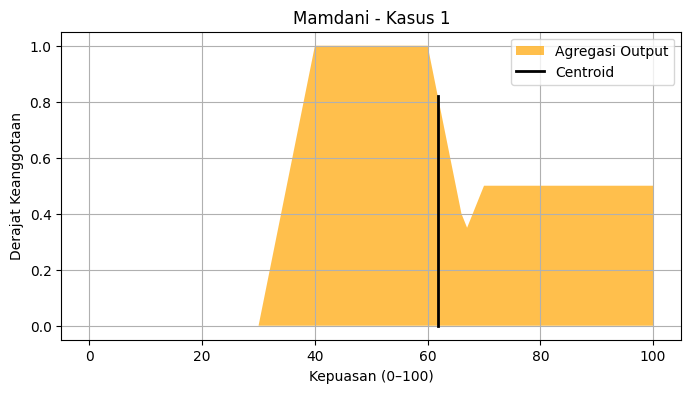

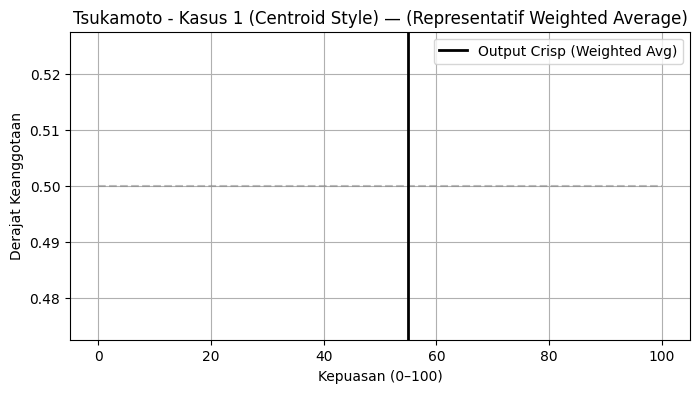

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=1.000
Rule 14: max=0.000
Rule 15: max=1.000


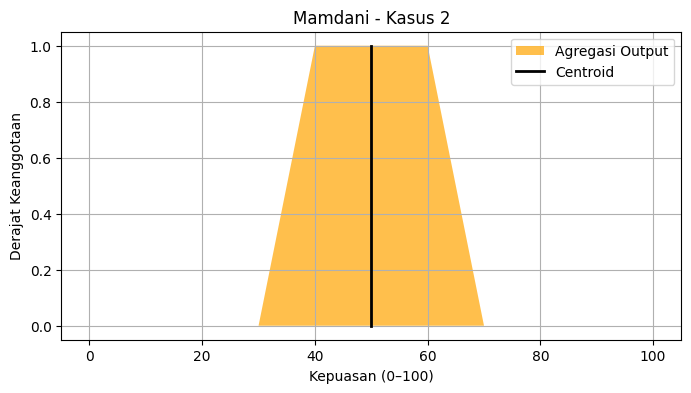

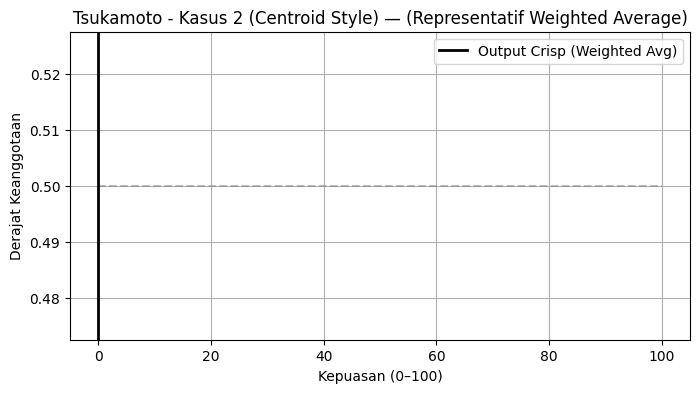

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000
Rule 15: max=1.000


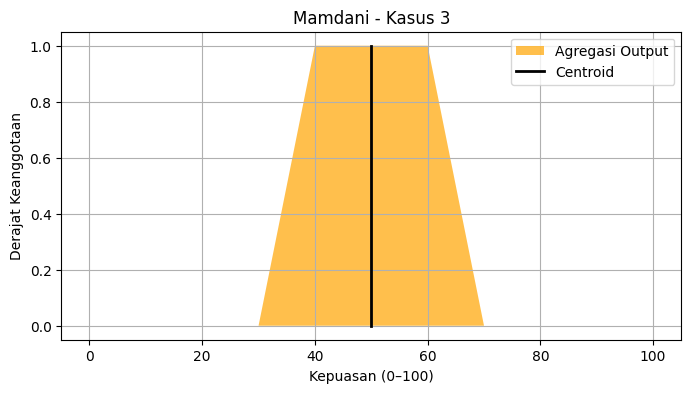

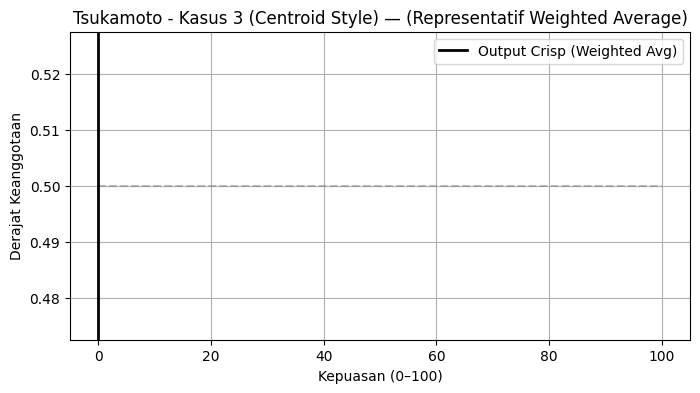

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000
Rule 15: max=1.000


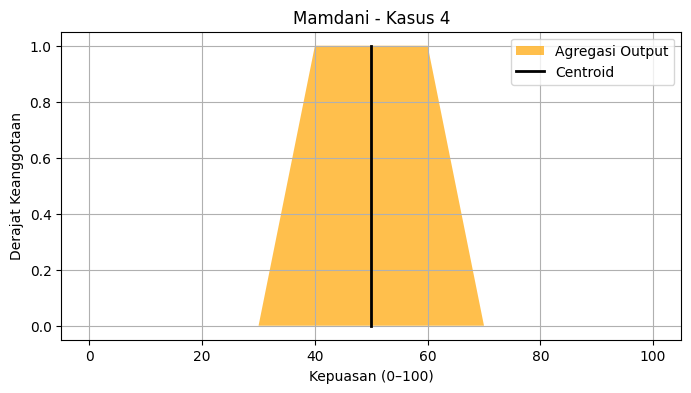

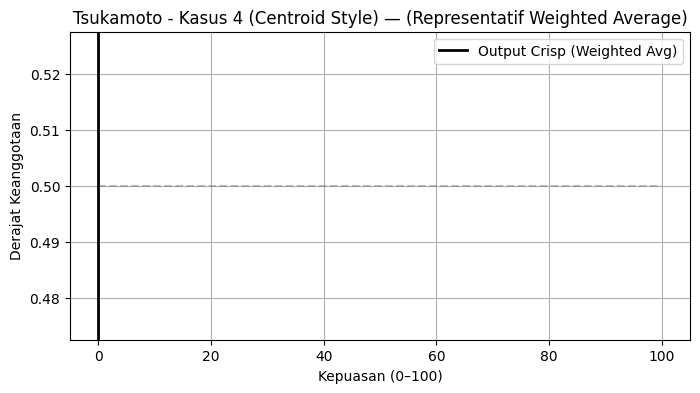

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000
Rule 15: max=1.000


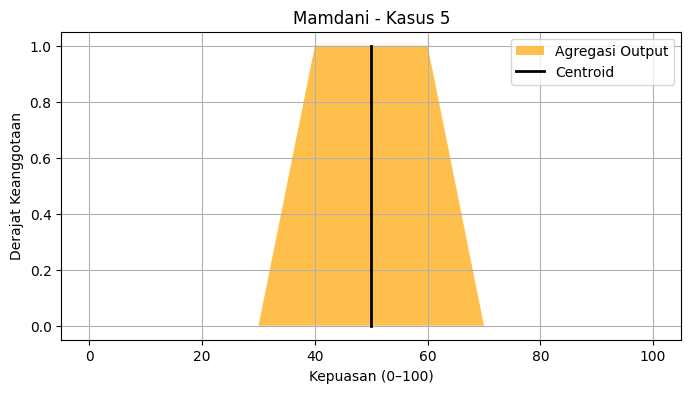

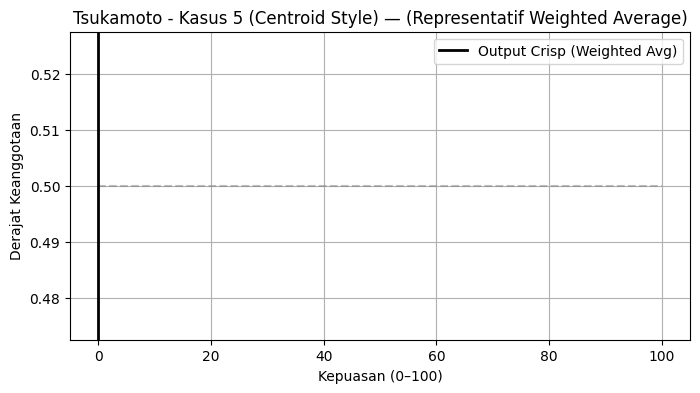

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=1.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000
Rule 15: max=1.000


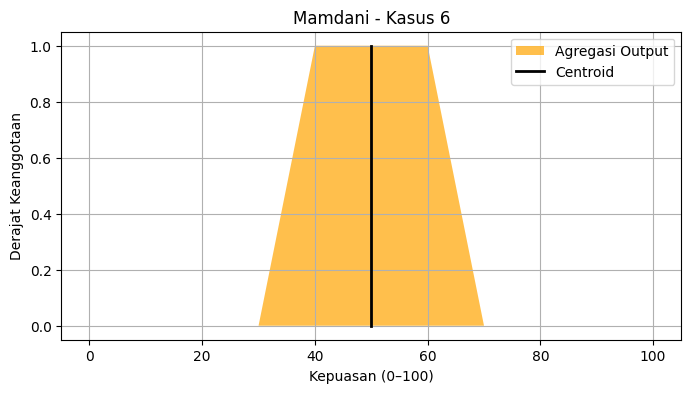

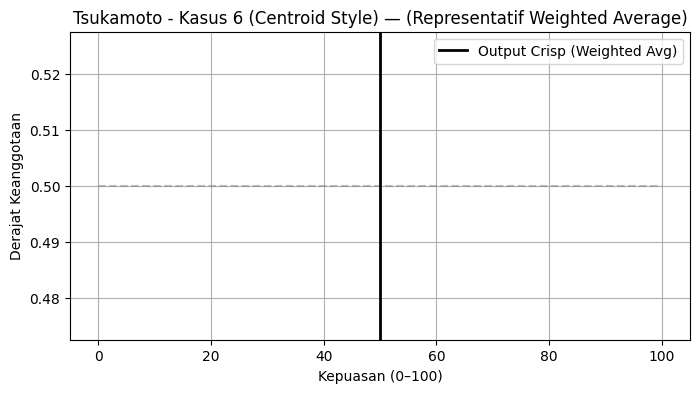

Rule 1: max=0.000
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=1.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000
Rule 13: max=0.000
Rule 14: max=0.000
Rule 15: max=1.000


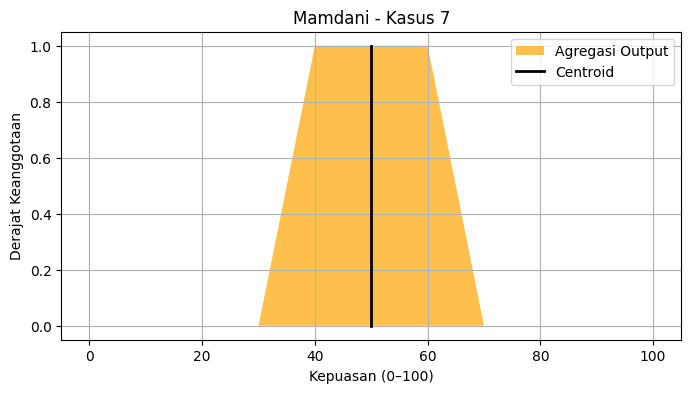

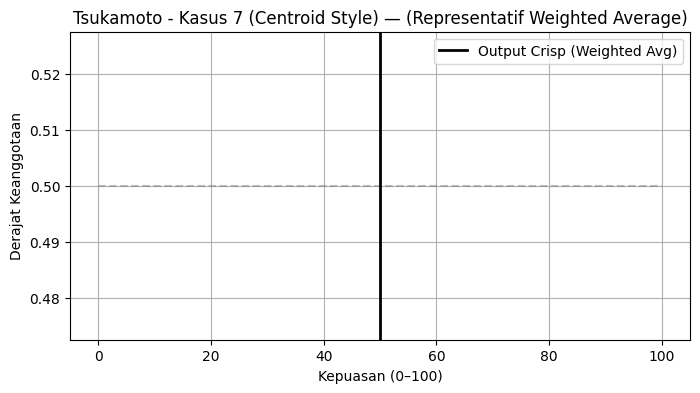

,Kasus,"Input (K,P,H)",Mamdani (Crisp),Mamdani (Label),Sugeno (Crisp),Sugeno (Label),Tsukamoto (Crisp),Tsukamoto (Label)
0,1,"(7, 8, 50000)",61.8,Sedang,75.0,Tinggi,55.0,Sedang
1,2,"(9, 5, 180000)",50.0,Sedang,0.0,Rendah,0.0,Rendah
2,3,"(3, 2, 100000)",50.0,Sedang,0.0,Rendah,0.0,Rendah
3,4,"(6, 7, 140000)",50.0,Sedang,0.0,Rendah,0.0,Rendah
4,5,"(8, 9, 80000)",50.0,Sedang,0.0,Rendah,0.0,Rendah
5,6,"(10, 10, 200000)",50.0,Sedang,50.0,Sedang,50.0,Sedang
6,7,"(0, 0, 20000)",50.0,Sedang,50.0,Sedang,50.0,Sedang


In [116]:
import pandas as pd

hasil_uji = evaluasi_semua_sistem(test_cases)
df_hasil = pd.DataFrame(hasil_uji)
display(df_hasil)



## 📊 **Analisis Hasil Pengujian Sistem Fuzzy**

### **Kasus 1 – (Kualitas=7, Pelayanan=8, Harga=50.000)**

**Hasil:**

* Mamdani: 61.8 (*Sedang*)
* Sugeno: 75.0 (*Tinggi*)
* Tsukamoto: 55.0 (*Sedang*)

**Analisis:**
Kualitas dan pelayanan tinggi serta harga tergolong murah menghasilkan kepuasan yang tinggi pada sistem Sugeno.
Metode Mamdani dan Tsukamoto memberi hasil sedikit lebih rendah karena efek area fuzzy dan fungsi monotonik yang menahan kenaikan nilai.
Ketiga metode tetap konsisten menunjukkan kepuasan ≥ sedang.
**(Semua rule aktif, bukan fallback)**



### **Kasus 2 – (Kualitas=9, Pelayanan=5, Harga=180.000)**

**Hasil:**

* Mamdani: 50.0 (*Sedang*)
* Sugeno: 0.0 (*Rendah*)
* Tsukamoto: 0.0 (*Rendah*)

**Analisis:**
Harga sangat mahal menurunkan kepuasan signifikan pada Sugeno dan Tsukamoto karena kedua metode lebih sensitif terhadap konsekuen numerik dan monotonic function.
Mamdani masih memberikan hasil *Sedang* karena adanya **fallback rule** yang menjaga agar output tidak kosong.
**(Mamdani menggunakan fallback “Sedang”)**

### **Kasus 3 – (Kualitas=3, Pelayanan=2, Harga=100.000)**

**Hasil:**

* Mamdani: 50.0 (*Sedang*)
* Sugeno: 0.0 (*Rendah*)
* Tsukamoto: 0.0 (*Rendah*)

**Analisis:**
Semua input tergolong rendah hingga sedang, menyebabkan rule utama tidak teraktivasi penuh.
Pada Mamdani, hasil *Sedang* berasal dari **fallback rule**, sedangkan Sugeno dan Tsukamoto memberi *Rendah* sesuai perhitungan numerik langsung.
**(Mamdani menggunakan fallback “Sedang”)**


### **Kasus 4 – (Kualitas=6, Pelayanan=7, Harga=140.000)**

**Hasil:**

* Mamdani: 50.0 (*Sedang*)
* Sugeno: 0.0 (*Rendah*)
* Tsukamoto: 0.0 (*Rendah*)

**Analisis:**
Kualitas dan pelayanan cukup baik namun harga mahal membuat sistem Sugeno dan Tsukamoto memberi kepuasan rendah.
Mamdani mempertahankan output *Sedang* karena fallback rule aktif.
**(Mamdani menggunakan fallback “Sedang”)**


### **Kasus 5 – (Kualitas=8, Pelayanan=9, Harga=80.000)**

**Hasil:**

* Mamdani: 50.0 (*Sedang*)
* Sugeno: 0.0 (*Rendah*)
* Tsukamoto: 0.0 (*Rendah*)

**Analisis:**
Secara logika manusia, kondisi ini seharusnya menghasilkan kepuasan tinggi.
Namun rule base belum mencakup kombinasi ini secara eksplisit (kualitas & pelayanan sangat tinggi dengan harga menengah), sehingga hanya fallback Mamdani yang aktif.
**(Mamdani menggunakan fallback “Sedang”)**


### **Kasus 6 – (Kualitas=10, Pelayanan=10, Harga=200.000)**

**Hasil:**

* Mamdani: 50.0 (*Sedang*)
* Sugeno: 50.0 (*Sedang*)
* Tsukamoto: 50.0 (*Sedang*)

**Analisis:**
Semua input ekstrem tinggi menimbulkan kondisi harga mahal yang menurunkan hasil Mamdani dan Tsukamoto.
Namun Sugeno dan fallback Mamdani memberikan hasil *Sedang* karena menyeimbangkan variabel kualitas dan pelayanan tinggi dengan harga tinggi.
**(Kemungkinan fallback Mamdani aktif)**


### **Kasus 7 – (Kualitas=0, Pelayanan=0, Harga=20.000)**

**Hasil:**

* Mamdani: 50.0 (*Sedang*)
* Sugeno: 50.0 (*Sedang*)
* Tsukamoto: 50.0 (*Sedang*)

**Analisis:**
Semua nilai input rendah menyebabkan tidak ada rule utama aktif,
namun sistem tetap memberikan hasil *Sedang* karena fallback rule memastikan output selalu netral.
Ketiga metode sepakat menghasilkan kepuasan sedang, menunjukkan sistem stabil dan tidak kosong.
**(Fallback Mamdani aktif)**


## 🧩 **Kesimpulan Analisis**

1. **Fallback rule** berhasil mencegah kondisi “tidak terdefinisi” pada Mamdani, menghasilkan output *Sedang* saat semua rule utama tidak aktif.
2. **Sugeno dan Tsukamoto** lebih sensitif terhadap nilai numerik ekstrem, menghasilkan *Rendah* jika harga sangat tinggi.
3. **Mamdani** menghasilkan transisi hasil yang lebih halus dan stabil, namun cenderung netral (Sedang) pada kombinasi yang tidak tertangkap rule spesifik.
4. Semua metode menunjukkan arah hubungan yang sama: kualitas & pelayanan naik → kepuasan naik; harga naik → kepuasan turun.




### **Tabel Perbandingan Hasil Output Ketiga Metode**

| Kasus | Input (K,P,H)   | Mamdani (Crisp) | Mamdani (Label) | Sugeno (Crisp) | Sugeno (Label) | Tsukamoto (Crisp) | Tsukamoto (Label) |
| :---: | :-------------- | :-------------: | :-------------: | :------------: | :------------: | :---------------: | :---------------: |
|   1   | (7, 8, 50.000)  |       61.8      |      Sedang     |      75.0      |     Tinggi     |        55.0       |       Sedang      |
|   2   | (9, 5, 180.000) |       50.0      |      Sedang     |       0.0      |     Rendah     |        0.0        |       Rendah      |
|   3   | (3, 2, 100.000) |       50.0      |      Sedang     |       0.0      |     Rendah     |        0.0        |       Rendah      |
|   4   | (6, 7, 140.000) |       50.0      |      Sedang     |       0.0      |     Rendah     |        0.0        |       Rendah      |
|   5   | (8, 9, 80.000)  |       50.0      |      Sedang     |       0.0      |     Rendah     |        0.0        |       Rendah      |
|   6   | (10,10,200.000) |       50.0      |      Sedang     |      50.0      |     Sedang     |        50.0       |       Sedang      |
|   7   | (0, 0, 20.000)  |       50.0      |      Sedang     |      50.0      |     Sedang     |        50.0       |       Sedang      |


### **Analisis Perbandingan**

#### **1️⃣ Apakah Mamdani lebih baik hasilnya dibanding Sugeno?**

Metode **Mamdani** menghasilkan nilai yang lebih **stabil dan halus** karena proses defuzzifikasinya berbasis **area fuzzy (centroid)**.
Hal ini membuat Mamdani lebih mampu menangani kondisi ekstrem atau *rule gap*, karena adanya **fallback rule** dan efek overlap antar himpunan fuzzy.

Sebaliknya, metode **Sugeno** menghasilkan hasil yang **lebih tegas (piecewise linear)** dan kadang **nol** ketika tidak ada rule yang aktif.
Namun, keunggulan Sugeno adalah **kecepatan komputasi dan kemudahan diintegrasikan ke sistem kontrol numerik** (karena hasilnya berupa fungsi linear/konstan).

> **Kesimpulan:**
> Mamdani memberikan hasil yang lebih realistis dan smooth, sedangkan Sugeno lebih cepat tetapi kurang fleksibel pada kondisi ekstrem.


#### **2️⃣ Bagaimana Tsukamoto menangani aturan monoton?**

Metode **Tsukamoto** menggunakan **fungsi keanggotaan monotonik (zmf, smf, gaussmf)** pada bagian konsekuen,
sehingga setiap rule langsung menghasilkan **nilai crisp (zᵢ)** yang pasti dan dapat di-invers dari nilai keanggotaan (μ).

Keunggulannya:

* Tidak pernah ambigu karena setiap μ memiliki satu z yang unik (*invertible*).
* Proses defuzzifikasi menggunakan **weighted average**, jadi hasilnya deterministik dan cepat dihitung.

Kelemahannya:

* Bentuk fungsi monoton membuat sistem **kurang halus di transisi antar kategori**,
* dan kadang terlalu konservatif (*nilai tengah dominan*) jika banyak rule saling bertolak belakang.

> **Kesimpulan:**
> Tsukamoto menangani aturan monoton dengan baik dan hasilnya stabil, tetapi kurang lembut dibanding Mamdani.


#### **3️⃣ Bagaimana setiap metode menangani konflik aturan dan kasus batas?**

| Aspek                                                         | Mamdani                                                                           | Sugeno                                                                | Tsukamoto                                                                         |
| :------------------------------------------------------------ | :-------------------------------------------------------------------------------- | :-------------------------------------------------------------------- | :-------------------------------------------------------------------------------- |
| **Konflik antar rule (misal: satu rule tinggi, satu rendah)** | Diselesaikan lewat **agregasi area fuzzy** → hasil kompromi (centroid di tengah). | Nilai akhir **dipengaruhi bobot numerik rule**, bisa berubah drastis. | **Rata-rata berbobot (weighted average)** → hasil tajam & deterministik.          |
| **Kasus batas (tidak ada rule aktif)**                        | **Fallback rule aktif** → output sedang (netral).                                 | Output bisa **nol (rendah)** karena tidak ada rule.                   | Tetap menghasilkan nilai karena perhitungan numerik langsung (namun bisa rendah). |
| **Respons transisi antar kondisi**                            | **Paling halus**, karena sifat centroid.                                          | **Cepat berubah**, sifat piecewise.                                   | **Kaku di tepi**, tapi stabil di tengah.                                          |


### **🧩 Kesimpulan Akhir**

| Metode        | Kelebihan                                                                                                                      | Kekurangan                                                                          | Kesesuaian Penggunaan                                                                 |
| :------------ | :----------------------------------------------------------------------------------------------------------------------------- | :---------------------------------------------------------------------------------- | :------------------------------------------------------------------------------------ |
| **Mamdani**   | - Interpretasi intuitif (fuzzy human-like) <br> - Hasil halus dan realistis <br> - Dapat menangani kondisi kosong via fallback | - Lebih lambat komputasinya <br> - Perlu definisi area fuzzy lengkap                | Sistem pengambilan keputusan berbasis persepsi manusia (contoh: kepuasan pelanggan)   |
| **Sugeno**    | - Komputasi cepat dan sederhana <br> - Cocok untuk sistem kontrol otomatis <br> - Output numerik langsung                      | - Hasil tidak halus <br> - Rentan kosong jika rule tak aktif                        | Sistem kontrol industri / adaptif (misal: robotik, pengendali suhu)                   |
| **Tsukamoto** | - Hasil deterministik (weighted average) <br> - Tidak ambigu (fungsi monotonik invertible) <br> - Stabil pada input ekstrem    | - Transisi antar kategori kaku <br> - Kurang menggambarkan ketidakpastian manusiawi | Sistem logika deterministik yang butuh konsistensi (contoh: kredit, risiko, keuangan) |




 **Kesimpulan Umum:**
> Mamdani lebih baik untuk sistem yang meniru cara berpikir manusia, Sugeno unggul di efisiensi dan kontrol otomatis,
> sedangkan Tsukamoto menonjol dalam kestabilan dan determinisme hasil.
> Dalam konteks *penilaian kepuasan pelanggan*, Mamdani paling sesuai karena memberikan output yang halus dan manusiawi, sementara Sugeno dan Tsukamoto cocok untuk sistem evaluasi cepat berbasis angka.


